# Fig. 1 — ML-FTLE Composite Explainer

Generates the four-row figure (Fig. 1):

| Row        | Content                                                   |
| ---------- | --------------------------------------------------------- |
| 1 (Top)    | Scalar observable with N_SHOW highlighted sliding windows |
| 2          | log-GMAE vs horizon for each selected window              |
| 3          | Temporal R² of the OLS log-GMAE fit                       |
| 4 (Bottom) | ML-FTLE proxy vs QR-FTLE ground truth                     |

**Execution order:** `c01` → `c02` → `c03` → `c04` (once) → `c06` (repeat freely).


### c01_imports

Standard library and imports required by all cells.


In [11]:
import time
import warnings
import builtins

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import Normalize       
from matplotlib.cm import ScalarMappable         
import matplotlib.patheffects as pe             
import matplotlib.patches as mpatches
from pathlib import Path
from sklearn.neighbors import KNeighborsRegressor
from scipy.stats import gmean

warnings.filterwarnings('ignore')
print('Imports OK')


Imports OK


### c02_params


In [12]:
from parameters import discover_all_params

PARAM_SETS = discover_all_params()
print(f'{len(PARAM_SETS)} dataset(s) found.')

# Number of windows shown in Row 1 and Row 2 — must match len(MANUAL_PICKS[key]).
N_SHOW = 3

# Window highlight and curve colours (Window 1 = chaotic, Window 3 = stable).
WIN_COLORS = ['#d62728', '#e377c2', '#1f77b4']   # red, pink, blue

MANUAL_PICKS = {
    'data_1': [10, 50, 150],}   # adjust indices

# R² threshold above which the exponential divergence model is considered valid.
R2_GOOD = 0.7


def run_ode_dataset(data_id, P):
    global LLE_THRESH

    # Stability decision threshold .
    LLE_THRESH_FALLBACK = P.LLE_THRESH


Discovered 1 parameter file(s) in d:\NLD_PROJECT\ML_FTLE\publication code\parameters:
  ✓  data_1.py  →  OUT_DIR=d:\NLD_PROJECT\ML_FTLE\publication code\data\data_1
1 dataset(s) found.


### c03_core

Import the ML-FTLE estimator from the core module.

ftle_for_window() is the sole entry point used in c04_compute.


In [13]:
from core.ml_ftle import ftle_for_window
print('ftle_for_window imported OK')


ftle_for_window imported OK


### c04_compute — RUN ONCE PER SESSION

### For each dataset in PARAM_SETS:

1.  Load the scalar time series from P.ODE_CSV.
2.  Push hyper-parameters into builtins so that
    ftle_for_window() picks them up without explicit args.
3.  Slide a window of length L across the signal with
    stride P.T_STEP, calling ftle_for_window() once per
    window and storing (time, ftle, r2, …) as a DataFrame.
4.  Apply a median rolling smoother to suppress shot noise.
5.  Persist the result to ml_ftle.csv and to all_compute.


In [14]:
def _load_signal(P):
    """Read the first two columns of P.ODE_CSV as (time, signal)."""
    df = pd.read_csv(P.ODE_CSV)
    t  = df.iloc[:, 0].values.astype(float)
    x  = df.iloc[:, 1].values.astype(float)
    dt = float(np.median(np.diff(t)))
    return t, x, dt

all_compute = {}   # dataset_key → result dict consumed by c06_plot

for data_id, P in PARAM_SETS.items():
    print(f'\n{"="*60}\n  {data_id}\n{"="*60}')

    # Push hyper-parameters into builtins namespace.
    for _k, _v in dict(
        EMB_DIM=P.EMB_DIM,
        TAU=P.POINCARE_LAG, POINCARE_LAG=P.POINCARE_LAG,
        KNN_NEIGH=P.KNN_NEIGH,
        H_FTLE_MAX=P.H_FTLE_MAX, HORIZON_MAX=P.H_FTLE_MAX,
        TEST_RATIO=getattr(P, 'TEST_RATIO', 0.30),
        LLE_THRESH=P.LLE_THRESH,
        ODE_CSV=P.ODE_CSV, OUT_DIR=P.OUT_DIR,
    ).items():
        setattr(builtins, _k, _v)

    t_ts, signal, dt_sig = _load_signal(P)
    L             = P.T_WINDOW_STEPS
    step          = P.T_STEP
    idx_starts    = np.arange(0, t_ts.size - L + 1, step, dtype=int)
    centers       = t_ts[idx_starts + L // 2]
    total         = len(idx_starts)
    half_span     = (L - 1) * dt_sig / 2   # half-width of one window in time units
    print(f'  Windows: {total}  L={L}  step={step}  '
          f'EMB={P.EMB_DIM}  tau={P.POINCARE_LAG}')

    rows = []
    t0 = time.time(); next_tick = 0.1

    for k, (s, tc) in enumerate(zip(idx_starts, centers)):
        seg = signal[s: s + L]
        fv, _, _, meta = ftle_for_window(
            seg, dt_sig,
            m=P.EMB_DIM, k_neighbors=P.KNN_NEIGH, H_ftle=P.H_FTLE_MAX,
        )
        rows.append({
            'time':  float(tc),
            'ftle':  float(fv) if np.isfinite(fv) else 0.0,
            **{kk: vv for kk, vv in meta.items() if not isinstance(vv, list)},
        })

        frac = (k + 1) / total
        if frac >= next_tick or k == total - 1:
            print(f'  [{k+1:4d}/{total}] {frac*100:5.1f}%  '
                  f'FTLE={fv:+.4f}  r2={meta.get("r2", 0.0):.2f}  '
                  f'[{meta.get("reason","")}]')
            next_tick += 0.1

    df = pd.DataFrame(rows)
    # Median rolling smoother (window P.SMOOTH_WINDOW) — reduces shot-noise
    # outliers while preserving the macroscopic regime-shift shape.
    df['ftle_smooth'] = (
        df['ftle'].rolling(P.SMOOTH_WINDOW, center=True, min_periods=5).median()
    )

    out_csv = P.OUT_DIR / 'ml_ftle.csv'
    P.OUT_DIR.mkdir(parents=True, exist_ok=True)
    df.to_csv(out_csv, index=False)
    print(f'  Saved → {out_csv}')

    all_compute[data_id] = dict(
        P=P, t_ts=t_ts, signal=signal, dt_sig=dt_sig,
        L=L, step=step, half_span=half_span,
        idx_starts=idx_starts, centers=centers,
        df=df,
    )

print('\n✓ Compute complete.')



  data_1
  Windows: 184  L=500  step=30  EMB=8  tau=5
  [  19/184]  10.3%  FTLE=+0.0304  r2=0.88  []
  [  37/184]  20.1%  FTLE=+0.0085  r2=0.37  []
  [  56/184]  30.4%  FTLE=+0.0204  r2=0.84  []
  [  74/184]  40.2%  FTLE=+0.0079  r2=0.76  []
  [  92/184]  50.0%  FTLE=-0.0014  r2=0.02  []
  [ 111/184]  60.3%  FTLE=-0.0012  r2=0.02  []
  [ 129/184]  70.1%  FTLE=-0.0009  r2=0.01  []
  [ 148/184]  80.4%  FTLE=-0.0016  r2=0.05  []
  [ 166/184]  90.2%  FTLE=-0.0018  r2=0.04  []
  [ 184/184] 100.0%  FTLE=-0.0021  r2=0.05  []
  Saved → d:\NLD_PROJECT\ML_FTLE\publication code\data\data_1\ml_ftle.csv

✓ Compute complete.


In [15]:
# Publication-quality global rc settings.
plt.rcParams.update({
    'font.family':       'sans-serif',
    'axes.linewidth':    1.5,
    'xtick.major.width': 1.5,
    'ytick.major.width': 1.5,
    'xtick.major.size':  5,
    'ytick.major.size':  5,
})


def _find_qr(P):
    """Search standard locations for qr_ftle.csv; return (t, lam) or (None, None)."""
    for path in [
        P.OUT_DIR / 'qr_ftle.csv',
        P.ODE_CSV.parent / 'qr_ftle.csv',
        Path('./qr_ftle.csv'),
    ]:
        if path.exists():
            dq = pd.read_csv(path)
            t_col = 'time' if 'time' in dq.columns else dq.columns[0]
            # Prefer the smoothed column; fall back to raw ftle.
            v_col = next(
                (c for c in ('lam1_qr_smooth', 'ftle_smooth', 'ftle') if c in dq.columns),
                dq.columns[1],
            )
            return dq[t_col].values.astype(float), dq[v_col].values.astype(float)
    return None, None


def _gmae_curve(seg, m, tau, H, k_nn, test_ratio=0.30):
    """
    Recompute the log-GMAE divergence curve for one window segment.

    This reproduces the exact procedure inside ftle_for_window():
      1. Robust-scale the segment.
      2. Delay-embed into m-dimensional vectors.
      3. Chronological 70/30 train-test split.
      4. KNN regression (inverse-distance weights) on training set.
      5. GMAE of absolute errors on held-out test set.

    Returns
    -------
    horizons : 1-D int array of valid horizon indices
    log_gmae : 1-D float array of log(GMAE) values
    slope    : OLS slope (= reported lambda_ML for this window)
    """
    from scipy.stats import linregress

    # Robust scaling: zero-median, unit-IQR (matches ml_ftle.py).
    med = float(np.median(seg))
    iqr = float(np.percentile(seg, 75) - np.percentile(seg, 25))
    if iqr < 1e-12:
        iqr = float(np.std(seg)) + 1e-12
    x_sc = (seg - med) / iqr

    valid_h, valid_lg = [], []
    for h in range(1, H + 1):
        n_vecs = len(x_sc) - (m - 1) * tau - h
        if n_vecs < 20:
            continue
        X = np.column_stack([x_sc[i*tau: i*tau + n_vecs] for i in range(m)])
        y = x_sc[(m-1)*tau + h: (m-1)*tau + h + n_vecs]
        n_tr = int(n_vecs * (1.0 - test_ratio))
        if len(X) - n_tr < 2:
            continue
        knn = KNeighborsRegressor(n_neighbors=min(k_nn, n_tr), weights='distance')
        knn.fit(X[:n_tr], y[:n_tr])
        errs = np.abs(y[n_tr:] - knn.predict(X[n_tr:]))
        errs = np.maximum(errs, 1e-12)   # floor matches ftle_for_window()
        gm = float(gmean(errs))
        if gm > 0 and np.isfinite(gm):
            valid_h.append(h)
            valid_lg.append(np.log(gm))

    if len(valid_h) < 3:
        return None, None, None

    hs = np.array(valid_h, float)
    lg = np.array(valid_lg, float)
    slope, intercept, *_ = linregress(hs, lg)
    return hs, lg, float(slope)



### c06_plot — re-run freely after c04_compute

Generates the four-row composite figure (Fig. 1):

Row 1 Scalar observable with N_SHOW window spans highlighted.

Row 2 log-GMAE divergence curves for each selected window,
recomputed from the raw segment using the same
KNN-GMAE procedure as ftle_for_window() so that the
displayed slope matches the reported λ_ML exactly.

Row 3 Temporal evolution of the OLS R² of the log-GMAE fit,
confirming validity of the exponential-divergence model.

Row 4 Dual-axis overlay of smoothed ML-FTLE proxy (red, left
axis) and QR-FTLE ground truth (blue, right axis).



Generating 2x2 Fig. 1 for: data_1

✓ Figure saved → d:\NLD_PROJECT\ML_FTLE\publication code\data\data_1\Figure\Fig_1.pdf


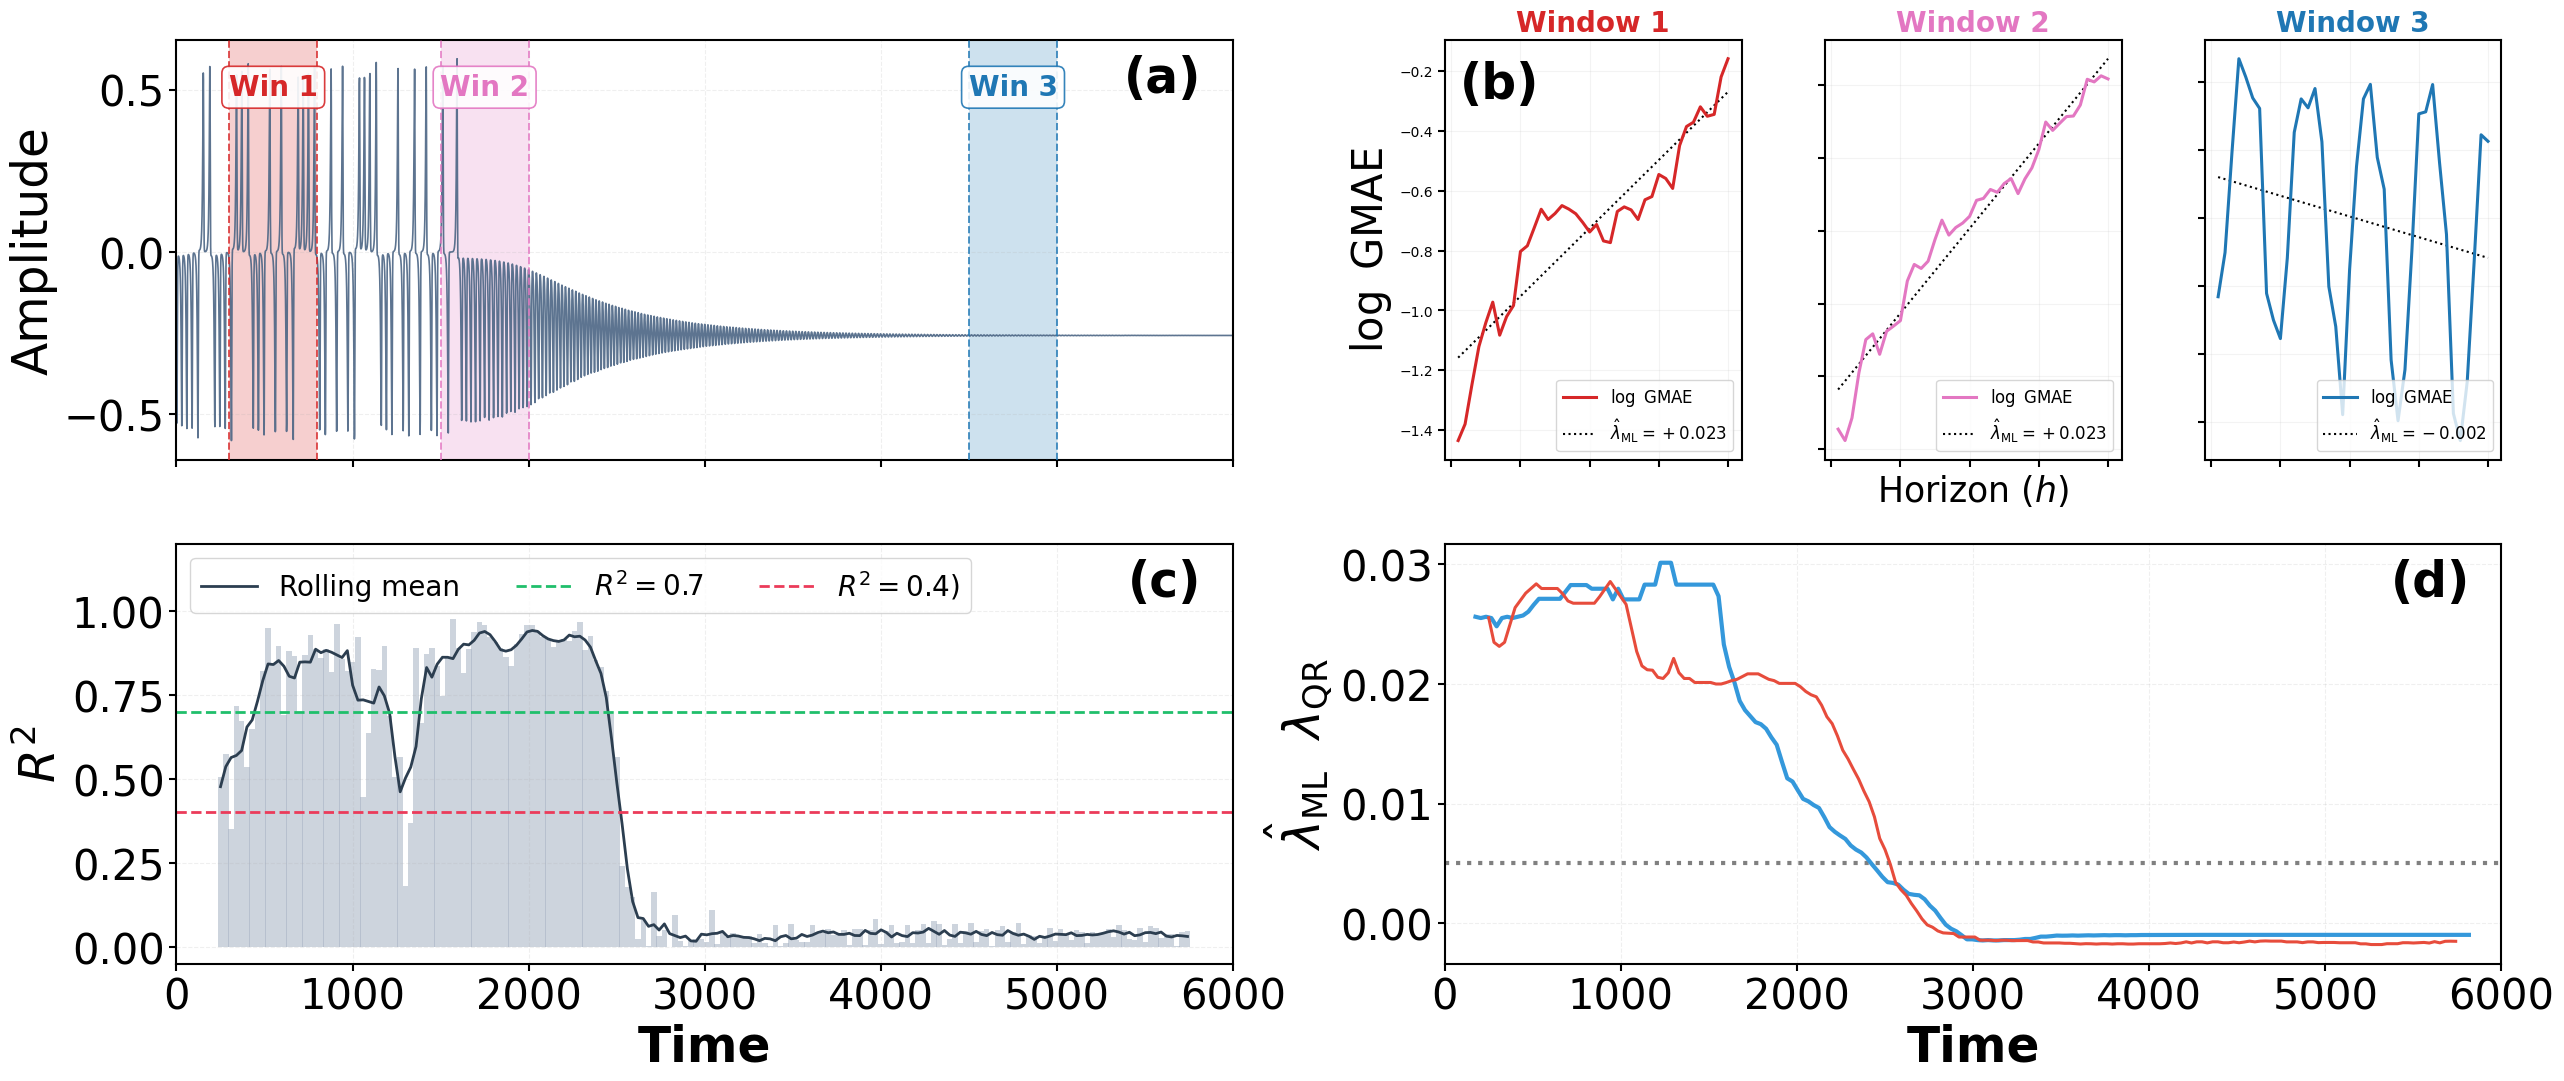

In [ ]:
def generate_publication_figure(data_id, C):
    """
    Build and save a 2x2 composite figure for one dataset.

    Parameters
    ----------
    data_id : str   Dataset key (e.g. 'data_1').
    C       : dict  Entry from all_compute produced by c04_compute.
    """
    P          = C['P']
    t_ts       = C['t_ts']
    signal     = C['signal']
    L          = C['L']
    idx_starts = C['idx_starts']
    df         = C['df']
    thresh     = P.LLE_THRESH

    # ── 1. Resolve window picks ──────────────────────────────────────────────
    manual = MANUAL_PICKS.get(data_id, [])
    if manual and len(manual) == N_SHOW:
        picks = [int(i) for i in manual]
    else:
        if manual:
            print(f'  [warn] MANUAL_PICKS["{data_id}"] has {len(manual)} entries '
                  f'but N_SHOW={N_SHOW}; falling back to auto-spread.')
        picks = list(np.linspace(0, len(df) - 1, N_SHOW, dtype=int))

    # Clamp to valid range.
    picks = [max(0, min(int(i), len(df) - 1)) for i in picks]

    # ── 2. Load QR ground truth ──────────────────────────────────────────────
    t_qr, lam_qr = _find_qr(P)

    # ── 3. Figure layout (2x2 Grid) ──────────────────────────────────────────
    # Increased width to 24 to comfortably fit the 2x2 layout with large fonts
    fig = plt.figure(figsize=(30, 12)) 
    gs  = gridspec.GridSpec(
        2, 2, 
        height_ratios=[1, 1], 
        width_ratios=[1, 1],
        hspace=0.2, 
        wspace=0.2
    )

    # ── PANEL (a): Scalar observable with window spans (Top-Left) ────────────
    ax0 = fig.add_subplot(gs[0, 0])
    ax0.plot(t_ts, signal, color='#4b6584', lw=1.2, alpha=0.9, zorder=2)

    for rank, wi in enumerate(picks):
        s   = idx_starts[wi]
        t_lo = t_ts[s]
        t_hi = t_ts[min(s + L - 1, len(t_ts) - 1)]
        
        # Safely wrap around the color list using modulo
        c = WIN_COLORS[rank % len(WIN_COLORS)] 
        
        ax0.axvspan(t_lo, t_hi, alpha=0.22, color=c, linewidth=0, zorder=1)
        ax0.axvline(t_lo, color=c, lw=1.4, ls='--', alpha=0.8, zorder=3)
        ax0.axvline(t_hi, color=c, lw=1.4, ls='--', alpha=0.8, zorder=3)

    y_lo, y_hi = ax0.get_ylim()
    y_label = y_hi - 0.08 * (y_hi - y_lo)
    for rank, wi in enumerate(picks):
        s    = idx_starts[wi]
        t_lo = t_ts[s]
        t_hi = t_ts[min(s + L - 1, len(t_ts) - 1)]
        c = WIN_COLORS[rank % len(WIN_COLORS)]
        ax0.text(
            (t_lo + t_hi) / 2, y_label,
            f'Win {rank + 1}',
            ha='center', va='top', fontsize=20,
            color = WIN_COLORS[rank % len(WIN_COLORS)], fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.25', facecolor='white',
                      edgecolor=WIN_COLORS[rank % len(WIN_COLORS)], alpha=0.9, lw=1.2),
            zorder=5,
        )

    ax0.set_xlim(t_ts.min(), t_ts.max())
    ax0.set_ylabel('Amplitude', fontsize=35)
    plt.setp(ax0.get_xticklabels(), visible=False)
    
    # Anchored to bottom-right corner using transAxes
    ax0.text(0.97, 0.85, '(a)', transform=ax0.transAxes, fontsize=35, fontweight='bold', va='bottom', ha='right')
    ax0.tick_params(labelsize=30, length=5)
    ax0.grid(True, alpha=0.2, ls='--')


    # ── PANEL (b): log-GMAE divergence curves (Top-Right) ────────────────────
    gs_div = gridspec.GridSpecFromSubplotSpec(
        1, N_SHOW, subplot_spec=gs[0, 1], wspace=0.28
    )

    for rank, wi in enumerate(picks):
        ax = fig.add_subplot(gs_div[rank])
        row = df.iloc[wi]
        s_w = idx_starts[wi]
        seg = signal[s_w: s_w + L]

        hs, lg, slope = _gmae_curve(
            seg,
            m=P.EMB_DIM,
            tau=P.POINCARE_LAG,
            H=P.H_FTLE_MAX,
            k_nn=P.KNN_NEIGH,
            test_ratio=getattr(P, 'TEST_RATIO', 0.30),
        )

        if hs is not None:
            ax.plot(hs, lg, color=WIN_COLORS[rank % len(WIN_COLORS)], lw=2.2, zorder=3, label=r'$\log$ GMAE')
            from scipy.stats import linregress
            _, intercept, *_ = linregress(hs, lg)
            ax.plot(hs, slope * hs + intercept, color='black', lw=1.5, ls=':', 
                    label=fr'$\hat{{\lambda}}_{{\mathrm{{ML}}}}={slope:+.3f}$')
            ax.legend(fontsize=12, loc='lower right')
        else:
            ax.text(
                0.5, 0.5,
                'Stable\n' r'$\hat{\lambda}_{\mathrm{ML}} \approx 0$',
                transform=ax.transAxes, ha='center', va='center',
                fontsize=14, color='gray', style='italic',
            )

        if rank == 1:
            ax.set_xlabel('Horizon $(h)$', fontsize=25)
        if rank == 0:
            ax.set_ylabel(r'$\log$ GMAE', fontsize=30)
            # Add (b) label only to the first sub-panel to represent the whole block
            ax.text(0.05, 0.95, '(b)', transform=ax.transAxes, fontsize=35, fontweight='bold', va='top', ha='left')
            
        plt.setp(ax.get_xticklabels(), visible=False)
        if rank > 0:
            plt.setp(ax.get_yticklabels(), visible=False)
            
        ax.set_title(f'Window {rank + 1}', fontsize=20, color=WIN_COLORS[rank % len(WIN_COLORS)], fontweight='bold')
        ax.grid(True, alpha=0.15)


    # ── PANEL (c): R² temporal track (Bottom-Left) ───────────────────────────
    ax2 = fig.add_subplot(gs[1, 0])
    if 'r2' in df.columns:
        r2  = df['r2'].fillna(0).astype(float)
        bar_w = (t_ts.max() - t_ts.min()) / (len(df) * 1.05)
        ax2.bar(df['time'], r2, width=bar_w, color='#a5b1c2', alpha=0.55, linewidth=0)
        ax2.plot(df['time'], r2.rolling(5, center=True, min_periods=1).mean(),
                 color='#2c3e50', lw=2.0, label='Rolling mean')
        ax2.axhline(R2_GOOD, color='#20bf6b', ls='--', lw=2,
                    label=fr'$R^2 = {R2_GOOD}$')
        ax2.axhline(0.4, color='#eb3b5a', ls='--', lw=2,
                    label=r'$R^2 = 0.4$)')
        ax2.set_ylim(-0.05, 1.2)

    ax2.set_xlim(t_ts.min(), t_ts.max())
    ax2.set_xlabel('Time', fontsize=35, fontweight='bold')
    ax2.set_ylabel(r'$R^2$', fontsize=35, fontweight='bold')
    ax2.text(0.97, 0.85, '(c)', transform=ax2.transAxes, fontsize=35, fontweight='bold', va='bottom', ha='right')
    ax2.tick_params(labelsize=30, length=5)
    ax2.legend(fontsize=20, loc='upper left', ncol=3)
    ax2.grid(True, alpha=0.2, ls='--')


    # ── PANEL (d):  ML vs QR comparison (Bottom-Right) ──────────────
    ax3L = fig.add_subplot(gs[1, 1])
    #ax3R = ax3L.twinx()

    l1, = ax3L.plot(
        df['time'], df['ftle_smooth'],
        color='#e74c3c', lw=2.2, zorder=4,
        label=r'$\hat{\lambda}_{\mathrm{ML}}$ ',
    )
    l2, = ax3L.plot(
            t_qr, lam_qr,
            color='#3498db', lw=3, alpha=1, zorder=3,
            label=r'$\lambda_{\mathrm{QR}}$',
        )
    ax3L.axhline(
        thresh, color='gray', ls=':', lw=3, alpha=1, zorder=1,
        label=fr'Stability threshold ($\lambda = {thresh}$)',
    )
    ax3L.set_ylabel(r'$\hat{\lambda}_{\mathrm{ML}}~~\lambda_{\mathrm{QR}}$', fontsize=35, fontweight='bold')
    ax3L.tick_params(axis='y', labelsize=30)
    """ 
    all_lines = [l1]
    if t_qr is not None:
        l2, = ax3R.plot(
            t_qr, lam_qr,
            color='#3498db', lw=2.2, alpha=0.85, zorder=3,
            label=r'$\lambda_{\mathrm{QR}}$',
        )
        ax3R.set_ylabel(r'$\lambda_{\mathrm{QR}}$', fontsize=35, color='#3498db', fontweight='bold')
        ax3R.tick_params(axis='y', labelcolor='#3498db', labelsize=30)
        all_lines.append(l2)
    """
    

    #ax3L.legend(all_lines, [l.get_label() for l in all_lines], fontsize=14, loc='upper right')
    ax3L.set_xlabel('Time', fontsize=35, fontweight='bold')
    ax3L.text(0.97, 0.85, '(d)', transform=ax3L.transAxes, fontsize=35, fontweight='bold', va='bottom', ha='right')
    ax3L.tick_params(axis='x', labelsize=30, length=5)
    ax3L.grid(True, alpha=0.2, ls='--')
    ax3L.set_xlim(t_ts.min(), t_ts.max())

    # ── 4. Save ──────────────────────────────────────────────────────────────
    fig_dir  = P.OUT_DIR / 'Figure'
    fig_dir.mkdir(parents=True, exist_ok=True)
    out_path = fig_dir / f'Fig_1.pdf'
    plt.savefig(out_path, dpi=1200, bbox_inches='tight')
    print(f'\n✓ Figure saved → {out_path}')
    plt.show()
    plt.close(fig)


# ── Execute for every loaded dataset ────────────────────────────────────────
assert 'all_compute' in globals(), "Run c04_compute first."
for data_id, C in all_compute.items():
    print(f'\nGenerating 2x2 Fig. 1 for: {data_id}')
    generate_publication_figure(data_id, C)